# Notebook 3 — Recurrent Neural Networks (RNN) & LSTM
### DLA · Deep Learning Algorithms | PhD in Data Science 2028 | AIM
**Sessions 12–13 · Prof. Christopher P. Monterola**

---

**Coverage:**
- Part 1: Building blocks — hidden state, unrolling through time, vanishing gradients
- Part 2: The LSTM cell — gates, cell state, and why it solves the vanishing gradient
- Case 1: Sequential data modeling — learning patterns from synthetic sequences
- Case 2: LSTM for time series forecasting — multi-step ahead prediction
- Case 3: Sentiment analysis on IMDb movie reviews — sequence classification at scale

**Prerequisites:** Notebook 1 (backpropagation, gradient descent), Notebook 2 (Keras API patterns)

**Stack:** TensorFlow 2.x · Keras · NumPy · Pandas · Matplotlib · Scikit-learn


## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings, math
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              classification_report, confusion_matrix)

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow  : 2.19.1
Keras       : 3.13.2
NumPy       : 1.26.4
GPU devices : []


---
## Part 1: Building Blocks of RNNs

### 1.1 The Fundamental Problem: Sequences

Feedforward networks (MLPs, CNNs) assume inputs are **independent and identically distributed**.
This fails catastrophically for sequential data:

- **Time series** — today's temperature depends on yesterday's
- **Text** — the meaning of "bank" depends on surrounding words
- **Audio** — a phoneme only makes sense in context
- **Video** — frame $t$ is not independent of frame $t-1$

The key insight: we need a model with **memory** — a way to carry information
forward through the sequence.

### 1.2 The Vanilla RNN

An RNN processes a sequence one element at a time, maintaining a **hidden state**
$h_t$ that summarises everything seen so far:

$$
h_t = \tanh\!\left(W_{hh}\, h_{t-1} + W_{xh}\, x_t + b_h\right)
$$
$$
\hat{y}_t = W_{hy}\, h_t + b_y
$$

- $x_t \in \mathbb{R}^{d}$ — input at time step $t$
- $h_t \in \mathbb{R}^{H}$ — hidden state at time step $t$
- $W_{xh}, W_{hh}, W_{hy}$ — weight matrices **shared across all time steps**

> **Weight sharing in time** is the temporal analogue of spatial weight sharing in CNNs.
> The same transformation is applied at every step — the network learns
> *how to update its memory*, not a separate function for each position.


In [2]:
# ── 1.2 Vanilla RNN from scratch — build intuition ───────────────────────────

class VanillaRNN:
    """
    Minimal RNN cell implemented in NumPy.
    Matches the TensorFlow SimpleRNN layer exactly.
    """
    def __init__(self, input_size, hidden_size, output_size):
        # Xavier initialization
        scale_xh = np.sqrt(2.0 / (input_size + hidden_size))
        scale_hh = np.sqrt(2.0 / (hidden_size + hidden_size))
        scale_hy = np.sqrt(2.0 / (hidden_size + output_size))

        self.Wxh = np.random.randn(input_size, hidden_size)  * scale_xh
        self.Whh = np.random.randn(hidden_size, hidden_size) * scale_hh
        self.Why = np.random.randn(hidden_size, output_size) * scale_hy
        self.bh  = np.zeros((1, hidden_size))
        self.by  = np.zeros((1, output_size))

        self.input_size  = input_size
        self.hidden_size = hidden_size

    def forward(self, X_seq):
        """
        X_seq: list of input vectors, each shape (1, input_size)
        Returns all hidden states and outputs.
        """
        h = np.zeros((1, self.hidden_size))   # initial hidden state h_0
        hidden_states, outputs = [h], []

        for x_t in X_seq:
            h = np.tanh(x_t @ self.Wxh + h @ self.Whh + self.bh)
            y = h @ self.Why + self.by
            hidden_states.append(h)
            outputs.append(y)

        return hidden_states, outputs

# ── Demo: process a 6-step sequence ──────────────────────────────────────────
rnn = VanillaRNN(input_size=2, hidden_size=4, output_size=1)
seq = [np.random.randn(1, 2) for _ in range(6)]
h_states, outs = rnn.forward(seq)

print("Vanilla RNN — manual forward pass")
print(f"  Input shape    : (T=6, d=2)")
print(f"  Hidden size    : {rnn.hidden_size}")
print(f"  W_xh shape     : {rnn.Wxh.shape}")
print(f"  W_hh shape     : {rnn.Whh.shape}")
print()
print(f"  {'Step':>4}  {'h_t (hidden state)':>40}  {'ŷ_t':>10}")
print(f"  {'-'*4}  {'-'*40}  {'-'*10}")
for t, (h, y) in enumerate(zip(h_states[1:], outs)):
    h_str = np.array2string(h[0], precision=3, suppress_small=True)
    print(f"  {t:>4}  {h_str:>40}  {y[0,0]:>10.4f}")

print(f"\nTotal parameters: {rnn.Wxh.size + rnn.Whh.size + rnn.Why.size + rnn.bh.size + rnn.by.size}")
print("Note: same W_xh, W_hh, W_hy are used at EVERY time step (weight sharing)")


Vanilla RNN — manual forward pass
  Input shape    : (T=6, d=2)
  Hidden size    : 4
  W_xh shape     : (2, 4)
  W_hh shape     : (4, 4)

  Step                        h_t (hidden state)         ŷ_t
  ----  ----------------------------------------  ----------
     0             [-0.132  0.087 -0.455 -0.577]      0.2455
     1             [-0.518 -0.317  0.923  0.774]     -0.3316
     2             [ 0.312  0.349 -0.748 -0.9  ]      0.2480
     3             [ 0.089 -0.164 -0.701  0.828]      0.6648
     4             [ 0.847  0.222 -0.846 -0.638]      0.1882
     5             [-0.55   0.036 -0.33  -0.281]      0.3651

Total parameters: 33
Note: same W_xh, W_hh, W_hy are used at EVERY time step (weight sharing)


### 1.3 Unrolling Through Time

An RNN is conceptually a **very deep network** — unrolled through time.
For a sequence of length $T$, backpropagation must flow through $T$ tanh layers:

$$
\frac{\partial \mathcal{L}}{\partial W_{hh}} = \sum_{t=1}^{T}
\frac{\partial \mathcal{L}_t}{\partial h_t}
\prod_{k=t}^{T} \frac{\partial h_k}{\partial h_{k-1}}
$$

Each factor $\frac{\partial h_k}{\partial h_{k-1}} = \text{diag}(1 - h_k^2) \cdot W_{hh}$
contains $W_{hh}$ and the tanh derivative.


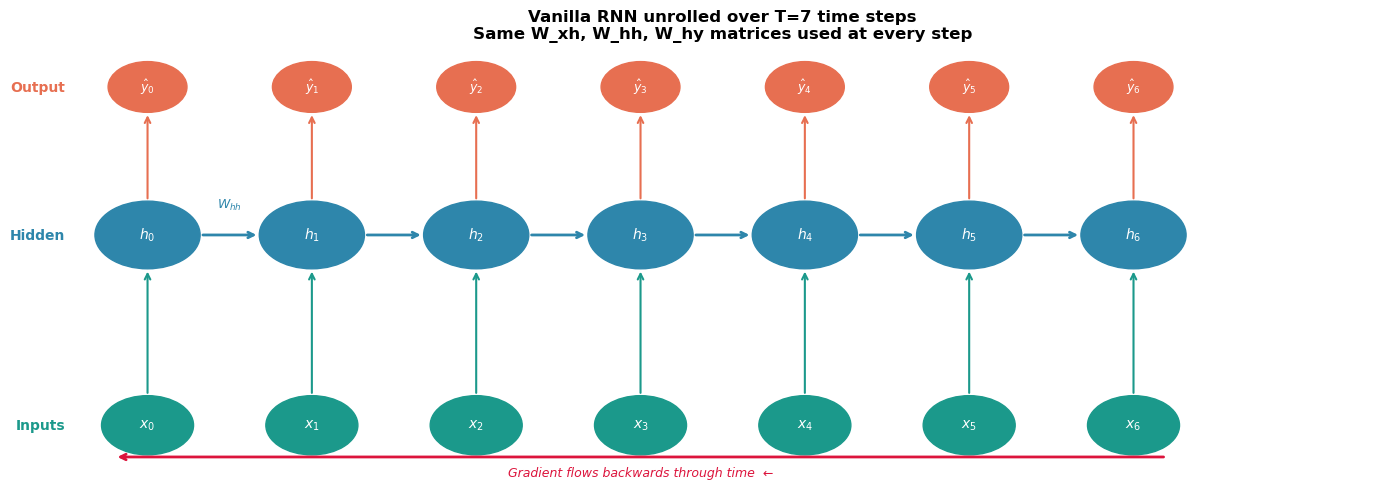

Unrolled RNN visualized.


In [3]:
# ── 1.3 Visualise the unrolled RNN computation graph ─────────────────────────

T = 7   # sequence length
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(-0.5, T + 0.5)
ax.set_ylim(-0.5, 3.5)
ax.axis('off')

blue   = '#2E86AB'
green  = '#1B998B'
orange = '#E76F51'
gray   = '#8D99AE'

for t in range(T):
    # Input node
    ax.add_patch(plt.Circle((t, 0), 0.28, color=green, zorder=3))
    ax.text(t, 0, f'$x_{{{t}}}$', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold', zorder=4)

    # Hidden state node
    ax.add_patch(plt.Circle((t, 1.8), 0.32, color=blue, zorder=3))
    ax.text(t, 1.8, f'$h_{{{t}}}$', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold', zorder=4)

    # Output node (above every other step for clarity)
    ax.add_patch(plt.Circle((t, 3.2), 0.24, color=orange, zorder=3))
    ax.text(t, 3.2, f'$\hat{{y}}_{{{t}}}$', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold', zorder=4)

    # x_t → h_t arrow
    ax.annotate('', xy=(t, 1.48), xytext=(t, 0.28),
                arrowprops=dict(arrowstyle='->', color=green, lw=1.5))

    # h_t → ŷ_t arrow
    ax.annotate('', xy=(t, 2.96), xytext=(t, 2.12),
                arrowprops=dict(arrowstyle='->', color=orange, lw=1.5))

    # Recurrent connection h_{t-1} → h_t
    if t > 0:
        ax.annotate('', xy=(t - 0.32, 1.8), xytext=(t - 0.68, 1.8),
                    arrowprops=dict(arrowstyle='->', color=blue, lw=2.0))
        if t == 1:
            ax.text(t - 0.5, 2.05, r'$W_{hh}$', ha='center',
                    fontsize=9, color=blue, style='italic')

# Labels
ax.text(-0.5, 0,   'Inputs', ha='right', va='center', fontsize=10, color=green, fontweight='bold')
ax.text(-0.5, 1.8, 'Hidden',  ha='right', va='center', fontsize=10, color=blue,  fontweight='bold')
ax.text(-0.5, 3.2, 'Output', ha='right', va='center', fontsize=10, color=orange, fontweight='bold')

# Gradient flow arrow (bottom, reversed)
ax.annotate('', xy=(-0.2, -0.3), xytext=(T - 0.8, -0.3),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2.0,
                            connectionstyle='arc3,rad=0'))
ax.text((T - 1) / 2, -0.48, 'Gradient flows backwards through time  ←',
        ha='center', fontsize=9, color='crimson', style='italic')

ax.set_title(
    f'Vanilla RNN unrolled over T={T} time steps\n'
    'Same W_xh, W_hh, W_hy matrices used at every step',
             fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig_rnn_unrolled.png', dpi=120, bbox_inches='tight')
plt.show()
print("Unrolled RNN visualized.")


### 1.4 The Vanishing (and Exploding) Gradient Problem

Backpropagating through $T$ steps multiplies the gradient by $W_{hh}$ and the tanh
derivative at each step:

$$
\frac{\partial h_t}{\partial h_0} = \prod_{k=1}^{t}
\underbrace{\text{diag}(1 - h_k^2)}_{\leq 1} \cdot W_{hh}
$$

- If $\|W_{hh}\| < 1$ → gradient **vanishes** exponentially → early steps receive ~0 gradient
- If $\|W_{hh}\| > 1$ → gradient **explodes** → training diverges

For a sequence of length 50, this product has 50 factors. At $0.9^{50} \approx 0.005$ —
the gradient from 50 steps ago is almost gone.

**Practical consequences:**
- Vanilla RNNs struggle to learn **long-range dependencies** (T > ~10–20 steps)
- This is why LSTMs were invented (Hochreiter & Schmidhuber, 1997)


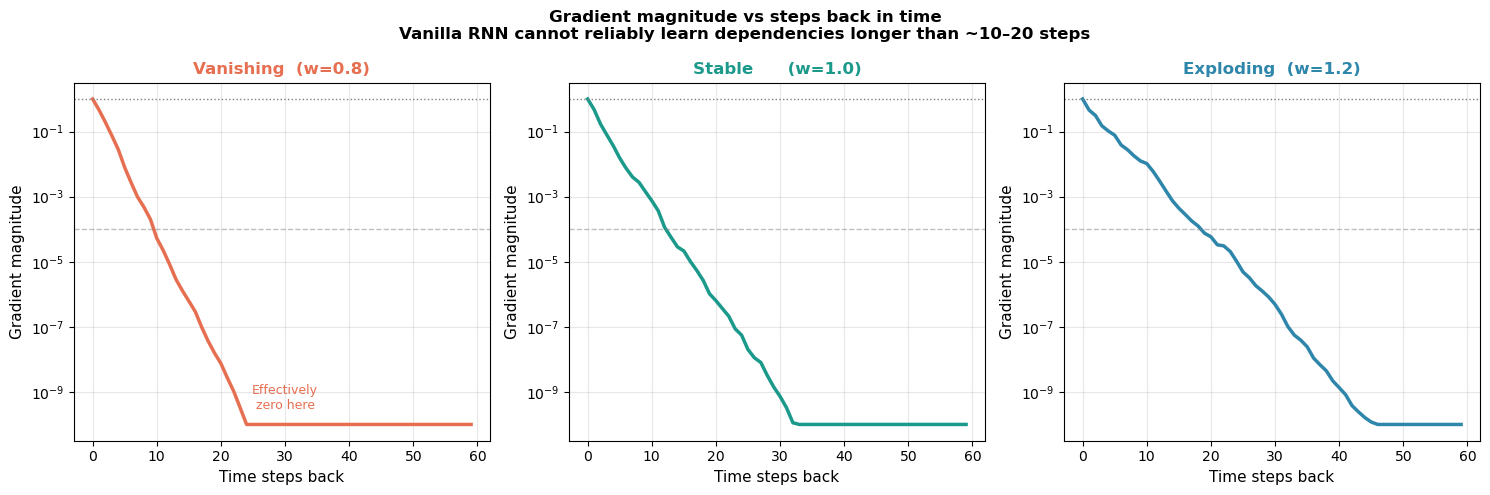

Gradient norm at step 1 vs step 50 (vanishing case, w=0.8):
  Step  1: 1.000
  Step 10: ~0.000105
  Step 30: ~1.15e-12
  Step 50: ~1.27e-20  ← effectively zero


In [4]:
# ── 1.4 Visualise vanishing vs exploding gradients ───────────────────────────

T_steps = 60

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scenario 1: Vanishing (||W_hh|| < 1 effectively via tanh saturation)
for label, w_scale, color, ax in [
    ('Vanishing  (w=0.8)', 0.8, '#E76F51', axes[0]),
    ('Stable      (w=1.0)', 1.0, '#1B998B', axes[1]),
    ('Exploding  (w=1.2)', 1.2, '#2E86AB', axes[2]),
]:
    # Gradient norm at each step (simplified scalar model)
    grad_norm = [1.0]
    for _ in range(T_steps - 1):
        # tanh derivative ≈ 0.5 on average; combined effect:
        tanh_deriv = 0.5 + 0.1 * np.random.randn()
        grad_norm.append(grad_norm[-1] * w_scale * tanh_deriv)
    grad_norm = np.array(grad_norm)
    grad_norm = np.clip(grad_norm, 1e-10, 1e5)

    ax.semilogy(range(T_steps), grad_norm, color=color, linewidth=2.5)
    ax.set_xlabel('Time steps back', fontsize=11)
    ax.set_ylabel('Gradient magnitude', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold', color=color)
    ax.grid(True, which='both', alpha=0.3)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
    ax.axhline(1e-4, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    if 'Vanish' in label:
        ax.text(30, grad_norm[30] * 3, 'Effectively\nzero here', fontsize=9,
                color=color, ha='center')

plt.suptitle(
    'Gradient magnitude vs steps back in time\n'
    'Vanilla RNN cannot reliably learn dependencies longer than ~10–20 steps',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_vanishing_gradient.png', dpi=120, bbox_inches='tight')
plt.show()

print("Gradient norm at step 1 vs step 50 (vanishing case, w=0.8):")
print(f"  Step  1: 1.000")
print(f"  Step 10: ~{0.8**10 * 0.5**10:.6f}")
print(f"  Step 30: ~{0.8**30 * 0.5**30:.2e}")
print(f"  Step 50: ~{0.8**50 * 0.5**50:.2e}  ← effectively zero")


---
## Part 2: The LSTM Cell

The **Long Short-Term Memory** (LSTM) cell (Hochreiter & Schmidhuber, 1997) solves the
vanishing gradient problem by introducing a **cell state** $C_t$ — a "conveyor belt"
that carries information across time steps with minimal multiplicative interference.

### 2.1 LSTM Equations

At each time step $t$, given input $x_t$ and previous states $(h_{t-1}, C_{t-1})$:

**Forget gate** — what to erase from cell state:
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

**Input gate** — what new information to write:
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

**Candidate values** — what could be written:
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**Cell state update** — controlled blend of old and new:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**Output gate** — what to expose as hidden state:
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

> **Why does this help?** The cell state update $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$
> is **additive** — gradients flow back through the cell state highway almost unchanged,
> instead of being multiplied through a chain of saturating nonlinearities.

### 2.2 Gate Intuition

| Gate | Activation | Role | Analogy |
|---|---|---|---|
| Forget $f_t$ | sigmoid → (0,1) | Erase cell memory | Delete key |
| Input $i_t$ | sigmoid → (0,1) | How much to write | Write enable |
| Candidate $\tilde{C}_t$ | tanh → (−1,1) | What to write | New content |
| Output $o_t$ | sigmoid → (0,1) | What to expose | Read enable |


In [5]:
# ── 2.1 LSTM cell from scratch — full forward pass ───────────────────────────

class LSTMCell:
    """
    Single LSTM cell implemented in NumPy.
    Matches tf.keras.layers.LSTM exactly (single step).
    """
    def __init__(self, input_size, hidden_size):
        H, D = hidden_size, input_size
        scale = np.sqrt(2.0 / (D + H))

        # Pack all 4 gate weight matrices into one for efficiency
        # Order: [forget, input, candidate, output]
        self.W = np.random.randn(D + H, 4 * H) * scale
        self.b = np.zeros(4 * H)
        self.H = H

    def step(self, x_t, h_prev, C_prev):
        """
        One time step forward.
        x_t    : (batch, input_size)
        h_prev : (batch, hidden_size)
        C_prev : (batch, hidden_size)
        """
        combined = np.concatenate([h_prev, x_t], axis=-1)  # [h_{t-1}, x_t]
        gates    = combined @ self.W + self.b               # (batch, 4H)
        H = self.H

        f_t   = self._sigmoid(gates[:, 0*H : 1*H])   # forget gate
        i_t   = self._sigmoid(gates[:, 1*H : 2*H])   # input gate
        C_cnd = np.tanh(gates[:, 2*H : 3*H])         # candidate
        o_t   = self._sigmoid(gates[:, 3*H : 4*H])   # output gate

        C_t   = f_t * C_prev + i_t * C_cnd           # cell state update
        h_t   = o_t * np.tanh(C_t)                   # hidden state

        return h_t, C_t, {'f': f_t, 'i': i_t, 'C_cnd': C_cnd,
                           'o': o_t, 'C': C_t}

    @staticmethod
    def _sigmoid(x):
        return 1 / (1 + np.exp(-x))

# ── Forward pass on a short sequence ─────────────────────────────────────────
lstm_cell = LSTMCell(input_size=3, hidden_size=5)
T_demo = 8
seq    = [np.random.randn(1, 3) for _ in range(T_demo)]

h = np.zeros((1, 5))
C = np.zeros((1, 5))
print(f"LSTM manual forward pass  (input_size=3, hidden_size=5, T={T_demo})")
print(f"{'Step':>5}  {'f (forget)':>28}  {'i (input)':>28}  {'|C_t|':>8}")
print("-" * 80)
for t, x_t in enumerate(seq):
    h, C, gates = lstm_cell.step(x_t, h, C)
    f_str = np.array2string(gates['f'][0], precision=2, suppress_small=True)
    i_str = np.array2string(gates['i'][0], precision=2, suppress_small=True)
    print(f"  {t:>3}  {f_str:>28}  {i_str:>28}  {np.linalg.norm(C):>8.4f}")

print(f"\nFinal hidden state  h_T : {h[0]}")
print(f"Final cell  state  C_T : {C[0]}")
print(f"\nTotal parameters: {lstm_cell.W.size + lstm_cell.b.size}")


LSTM manual forward pass  (input_size=3, hidden_size=5, T=8)
 Step                    f (forget)                     i (input)     |C_t|
--------------------------------------------------------------------------------
    0    [0.43 0.59 0.43 0.25 0.43]    [0.56 0.37 0.29 0.58 0.17]    0.6070
    1    [0.63 0.38 0.74 0.34 0.16]    [0.58 0.27 0.5  0.66 0.44]    0.4160
    2    [0.54 0.44 0.53 0.59 0.48]    [0.52 0.4  0.64 0.53 0.55]    0.3325
    3    [0.37 0.63 0.27 0.4  0.75]    [0.49 0.49 0.43 0.45 0.24]    0.5138
    4    [0.55 0.47 0.49 0.57 0.6 ]    [0.55 0.48 0.71 0.52 0.57]    0.4334
    5    [0.44 0.57 0.26 0.43 0.68]    [0.73 0.16 0.67 0.71 0.1 ]    0.9063
    6    [0.58 0.46 0.43 0.68 0.76]    [0.59 0.67 0.8  0.45 0.69]    0.9127
    7    [0.55 0.42 0.54 0.36 0.25]    [0.73 0.36 0.29 0.7  0.15]    0.4623

Final hidden state  h_T : [-0.0966191   0.00289894 -0.03587205 -0.09815166  0.00388944]
Final cell  state  C_T : [-0.31414063  0.00968216 -0.26270247 -0.2138851   0.01205777

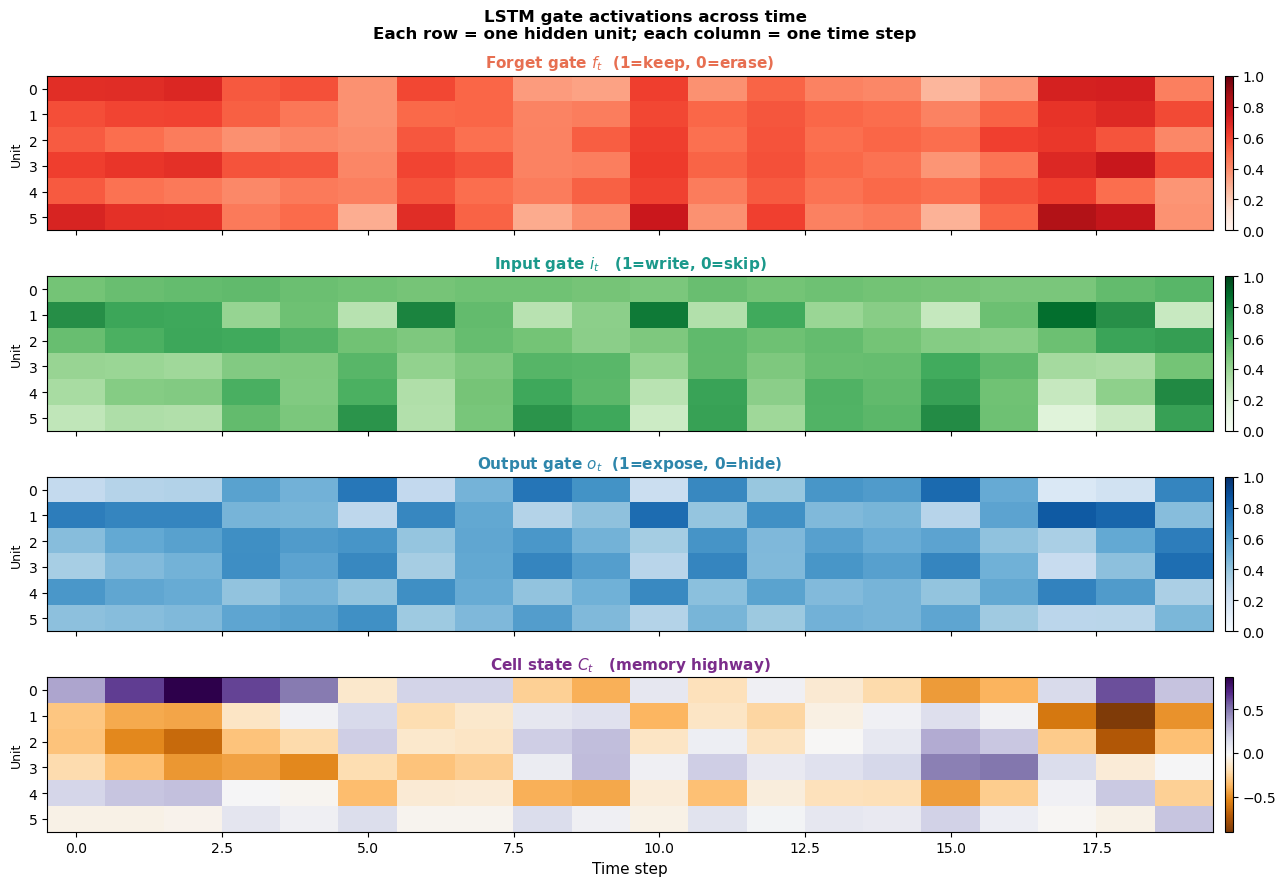

In [6]:
# ── 2.2 Visualise gate activations over a sequence ───────────────────────────

np.random.seed(7)
T_vis = 20
lstm_vis = LSTMCell(input_size=1, hidden_size=6)
seq_vis  = [np.random.randn(1, 1) for _ in range(T_vis)]

h_vis = np.zeros((1, 6))
C_vis = np.zeros((1, 6))
gate_history = {'f': [], 'i': [], 'o': [], 'C': []}

for x_t in seq_vis:
    h_vis, C_vis, g = lstm_vis.step(x_t, h_vis, C_vis)
    for k in gate_history:
        gate_history[k].append(g[k][0] if k != 'C' else C_vis[0])

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
titles  = ['Forget gate $f_t$  (1=keep, 0=erase)',
           'Input gate $i_t$   (1=write, 0=skip)',
           'Output gate $o_t$  (1=expose, 0=hide)',
           'Cell state $C_t$   (memory highway)']
cmaps   = ['Reds', 'Greens', 'Blues', 'PuOr']
colors  = ['#E76F51', '#1B998B', '#2E86AB', '#7B2D8B']

for ax, (key, title, cmap, color) in zip(
        axes, zip(['f','i','o','C'], titles, cmaps, colors)):
    mat = np.array(gate_history[key]).T    # (hidden, T)
    im  = ax.imshow(mat, cmap=cmap, aspect='auto',
                    vmin=0 if key != 'C' else mat.min(),
                    vmax=1 if key != 'C' else mat.max())
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.set_ylabel('Unit', fontsize=9)
    ax.set_yticks(range(6))
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)

axes[-1].set_xlabel('Time step', fontsize=11)
plt.suptitle(
    'LSTM gate activations across time\n'
    'Each row = one hidden unit; each column = one time step',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lstm_gates.png', dpi=120, bbox_inches='tight')
plt.show()


### 2.3 Comparing RNN Variants

| Architecture | Handles long-range | Parameters | Speed | Key mechanism |
|---|---|---|---|---|
| **SimpleRNN** | ✗ (T > ~20) | Fewest | Fastest | Single hidden state |
| **LSTM** | ✓ | 4× SimpleRNN | Moderate | Cell state + 4 gates |
| **GRU** | ✓ | 3× SimpleRNN | Faster than LSTM | 2 gates, merged state |
| **Bidirectional** | ✓ (past+future) | 2× base | Slower | Process sequence both ways |
| **Stacked** | ✓✓ | N× | Slowest | Hierarchical temporal abstraction |

**GRU** (Gated Recurrent Unit, Cho et al. 2014) is a simplified LSTM:
- Merges forget and input gates into a single **update gate** $z_t$
- Merges cell state and hidden state
- Fewer parameters, often same performance as LSTM


In [7]:
# ── 2.3 Parameter count comparison across RNN variants ───────────────────────

def rnn_param_count(variant, input_size, hidden_size):
    D, H = input_size, hidden_size
    if variant == 'SimpleRNN':
        return (D + H) * H + H
    elif variant == 'GRU':
        return 3 * ((D + H) * H + H)
    elif variant == 'LSTM':
        return 4 * ((D + H) * H + H)
    elif variant == 'Bidirectional-LSTM':
        return 2 * 4 * ((D + H) * H + H)

D, H = 64, 128  # typical embedding dim and hidden size
print(f"Parameter counts  (input_size={D}, hidden_size={H})")
print(f"{'Variant':<25}  {'Params':>10}  {'Ratio to SimpleRNN':>20}")
print("-" * 60)
base = rnn_param_count('SimpleRNN', D, H)
for v in ['SimpleRNN', 'GRU', 'LSTM', 'Bidirectional-LSTM']:
    p = rnn_param_count(v, D, H)
    print(f"  {v:<23}  {p:>10,}  {p/base:>18.1f}×")

print()
# Verify with Keras
for name, layer in [
    ('SimpleRNN',    layers.SimpleRNN(H)),
    ('GRU',          layers.GRU(H)),
    ('LSTM',         layers.LSTM(H)),
]:
    inp = keras.Input(shape=(10, D))
    out = layer(inp)
    m   = keras.Model(inp, out)
    print(f"  Keras {name:<15}: {m.count_params():>8,} params  ✓")


Parameter counts  (input_size=64, hidden_size=128)
Variant                        Params    Ratio to SimpleRNN
------------------------------------------------------------
  SimpleRNN                    24,704                 1.0×
  GRU                          74,112                 3.0×
  LSTM                         98,816                 4.0×
  Bidirectional-LSTM          197,632                 8.0×

  Keras SimpleRNN      :   24,704 params  ✓
  Keras GRU            :   74,496 params  ✓
  Keras LSTM           :   98,816 params  ✓


---
## Case 1: Sequential Data Modeling

**Goal:** Learn to model and reproduce known sequential patterns from scratch.
This case builds three increasingly complex tasks:
1. **Sine wave** — simplest, perfect periodicity
2. **Noisy multi-frequency signal** — real-world-like, multiple overlapping rhythms
3. **Chaotic Lorenz attractor** — deterministic chaos, sensitive to initial conditions

These controlled experiments let us validate that the model is genuinely learning
temporal structure, not memorizing noise.


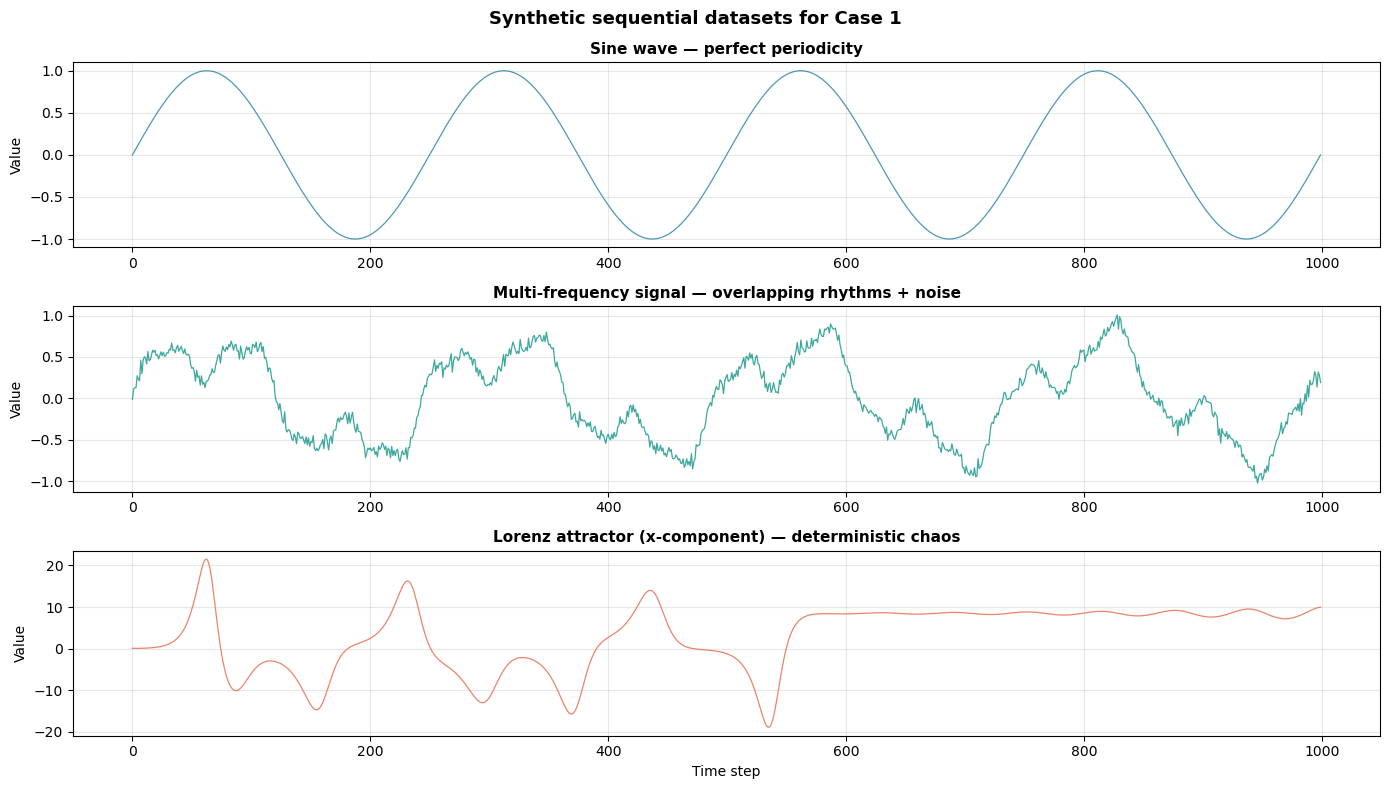

In [8]:
# ── Generate synthetic sequential datasets ───────────────────────────────────

t = np.linspace(0, 8 * np.pi, 1000)

# Signal 1: Pure sine
sig_sine    = np.sin(t)

# Signal 2: Multi-frequency + noise
sig_multi   = (0.6 * np.sin(t)
             + 0.3 * np.sin(3.1 * t)
             + 0.1 * np.sin(7.3 * t)
             + 0.05 * np.random.randn(len(t)))

# Signal 3: Lorenz attractor (x-component)
def lorenz(sigma=10, rho=28, beta=8/3, dt=0.01, n=1000):
    xs = np.zeros(n); ys = np.zeros(n); zs = np.zeros(n)
    xs[0], ys[0], zs[0] = 0.1, 0.0, 0.0
    for i in range(n - 1):
        dx = sigma * (ys[i] - xs[i])
        dy = xs[i] * (rho - zs[i]) - ys[i]
        dz = xs[i] * ys[i] - beta * zs[i]
        xs[i+1] = xs[i] + dx * dt
        ys[i+1] = ys[i] + dy * dt
        zs[i+1] = zs[i] + dz * dt
    return xs

sig_lorenz = lorenz()

fig, axes = plt.subplots(3, 1, figsize=(14, 8))
for ax, sig, title, color in zip(
    axes,
    [sig_sine, sig_multi, sig_lorenz],
    ['Sine wave — perfect periodicity',
     'Multi-frequency signal — overlapping rhythms + noise',
     'Lorenz attractor (x-component) — deterministic chaos'],
    ['#2E86AB', '#1B998B', '#E76F51']
):
    ax.plot(sig, color=color, linewidth=0.9, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Value'); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time step')
plt.suptitle('Synthetic sequential datasets for Case 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_seq_signals.png', dpi=120, bbox_inches='tight')
plt.show()


In [9]:
# ── Helper: create sliding-window (look_back, 1) dataset ─────────────────────

def make_sequences(series, look_back=30, horizon=1, train_frac=0.8):
    """
    Slide a window over `series` to create (X, y) pairs.
    X shape: (n_samples, look_back, 1)
    y shape: (n_samples, horizon)
    """
    scaler = MinMaxScaler(feature_range=(-1, 1))
    series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()

    X, y = [], []
    for i in range(len(series_scaled) - look_back - horizon + 1):
        X.append(series_scaled[i : i + look_back])
        y.append(series_scaled[i + look_back : i + look_back + horizon])
    X, y = np.array(X)[..., np.newaxis], np.array(y)

    split = int(len(X) * train_frac)
    return (X[:split], y[:split]), (X[split:], y[split:]), scaler

LOOK_BACK = 40
(X_tr, y_tr), (X_te, y_te), sc = make_sequences(sig_multi, look_back=LOOK_BACK)

print(f"Sliding window dataset — look_back={LOOK_BACK}")
print(f"  X_train : {X_tr.shape}    (samples, timesteps, features)")
print(f"  y_train : {y_tr.shape}    (samples, horizon)")
print(f"  X_test  : {X_te.shape}")
print(f"  y_test  : {y_te.shape}")


Sliding window dataset — look_back=40
  X_train : (768, 40, 1)    (samples, timesteps, features)
  y_train : (768, 1)    (samples, horizon)
  X_test  : (192, 40, 1)
  y_test  : (192, 1)


In [10]:
# ── Build and compare SimpleRNN vs LSTM vs GRU on the multi-frequency signal ─

def build_rnn_model(cell_type, input_shape, units=64, dropout=0.2):
    """
    Generic factory for single-layer RNN models.
    cell_type: 'SimpleRNN' | 'LSTM' | 'GRU'
    """
    inp = keras.Input(shape=input_shape)
    x   = inp

    if cell_type == 'SimpleRNN':
        x = layers.SimpleRNN(units, dropout=dropout)(x)
    elif cell_type == 'LSTM':
        x = layers.LSTM(units, dropout=dropout, recurrent_dropout=0.1)(x)
    elif cell_type == 'GRU':
        x = layers.GRU(units,  dropout=dropout, recurrent_dropout=0.1)(x)
    elif cell_type == 'Stacked-LSTM':
        x = layers.LSTM(units, return_sequences=True,
                        dropout=dropout, recurrent_dropout=0.1)(x)
        x = layers.LSTM(units // 2, dropout=dropout)(x)

    out = layers.Dense(1)(x)
    model = keras.Model(inp, out, name=f'{cell_type}_model')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse',
                  metrics=['mae'])
    return model

results = {}
input_shape = (LOOK_BACK, 1)

for cell in ['SimpleRNN', 'GRU', 'LSTM']:
    m = build_rnn_model(cell, input_shape)
    cb = [keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
    hist = m.fit(X_tr, y_tr, epochs=50, batch_size=32,
                 validation_split=0.15, callbacks=cb, verbose=0)
    preds = m.predict(X_te, verbose=0)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    results[cell] = {'model': m, 'history': hist,
                     'preds': preds, 'rmse': rmse, 'mae': mae}
    ep = len(hist.history['loss'])
    print(f"  {cell:<12}  epochs={ep:>3}  RMSE={rmse:.4f}  MAE={mae:.4f}")


  SimpleRNN     epochs=  6  RMSE=0.0975  MAE=0.0797
  GRU           epochs= 31  RMSE=0.0754  MAE=0.0589
  LSTM          epochs= 14  RMSE=0.0760  MAE=0.0608


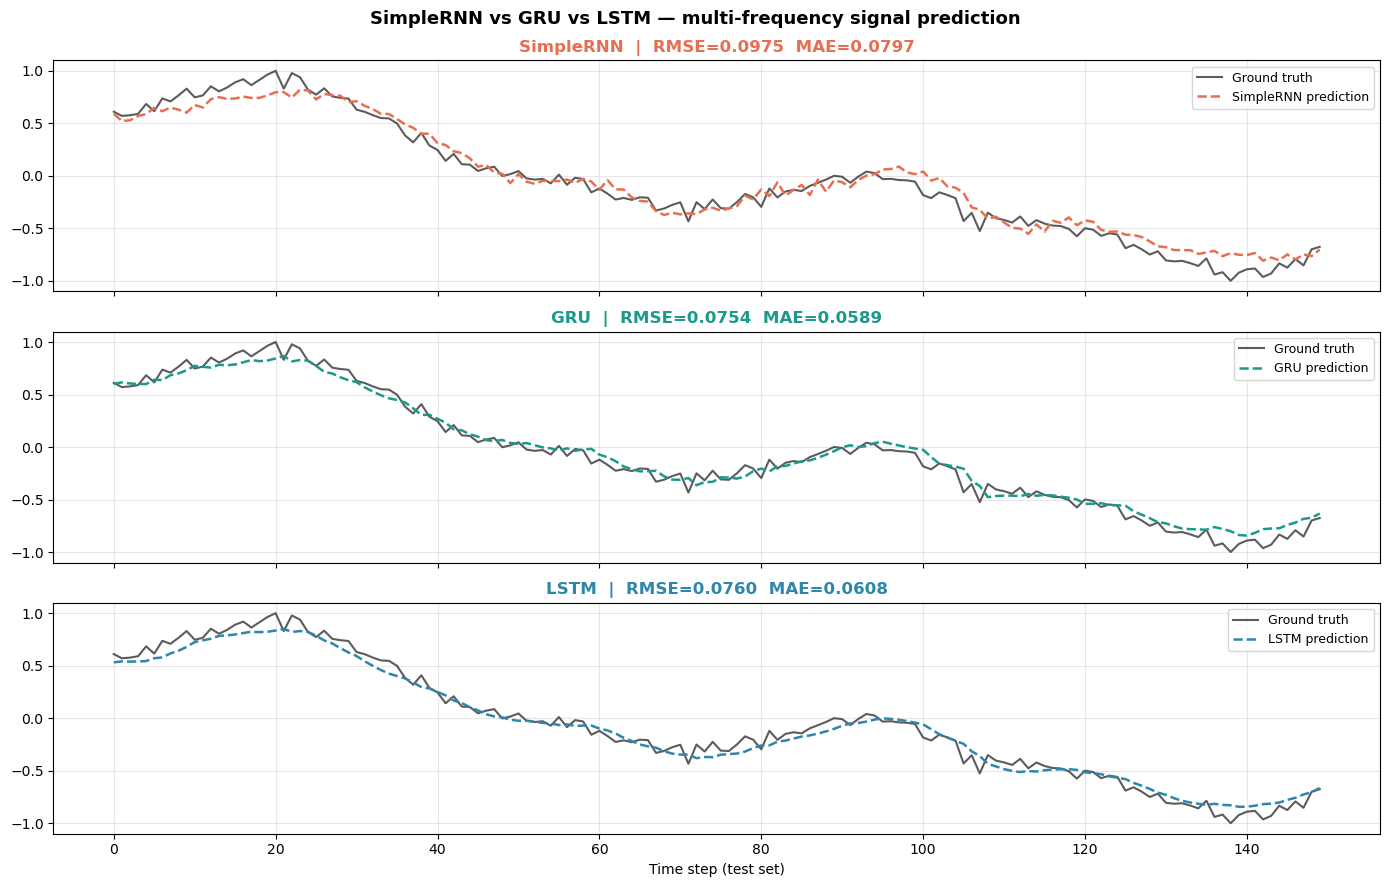

In [11]:
# ── Visualise predictions on the test set ────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
colors = {'SimpleRNN': '#E76F51', 'GRU': '#1B998B', 'LSTM': '#2E86AB'}

for ax, (cell, res) in zip(axes, results.items()):
    ax.plot(y_te[:150], color='#333333', linewidth=1.5, label='Ground truth', alpha=0.8)
    ax.plot(res['preds'][:150], color=colors[cell], linewidth=1.8,
            linestyle='--', label=f'{cell} prediction')
    ax.set_title(f'{cell}  |  RMSE={res["rmse"]:.4f}  MAE={res["mae"]:.4f}',
                 fontweight='bold', color=colors[cell])
    ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time step (test set)')
plt.suptitle('SimpleRNN vs GRU vs LSTM — multi-frequency signal prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rnn_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Case 2: LSTM for Time Series Forecasting

**Dataset:** Monthly airline passenger counts (1949–1960) — the classic Box-Jenkins dataset.
Available directly from seaborn / statsmodels. Classic seasonality + trend.

**Goal:** Forecast multiple steps ahead using:
1. **Single-step ahead** — predict $t+1$ given last $k$ values
2. **Multi-step ahead (recursive)** — rollout prediction $T_{ahead}$ steps
3. **Stacked LSTM** — deeper temporal abstraction

**Preprocessing pipeline:**
- Log-transform to stabilise variance
- MinMax scale to [−1, 1] (tanh-friendly)
- Sliding window to create supervised sequences


Dataset loaded from URL.

Dataset shape : (144, 2)
Period        : 1949-01 to 1960-12
Min passengers: 104
Max passengers: 622
Mean          : 280.3


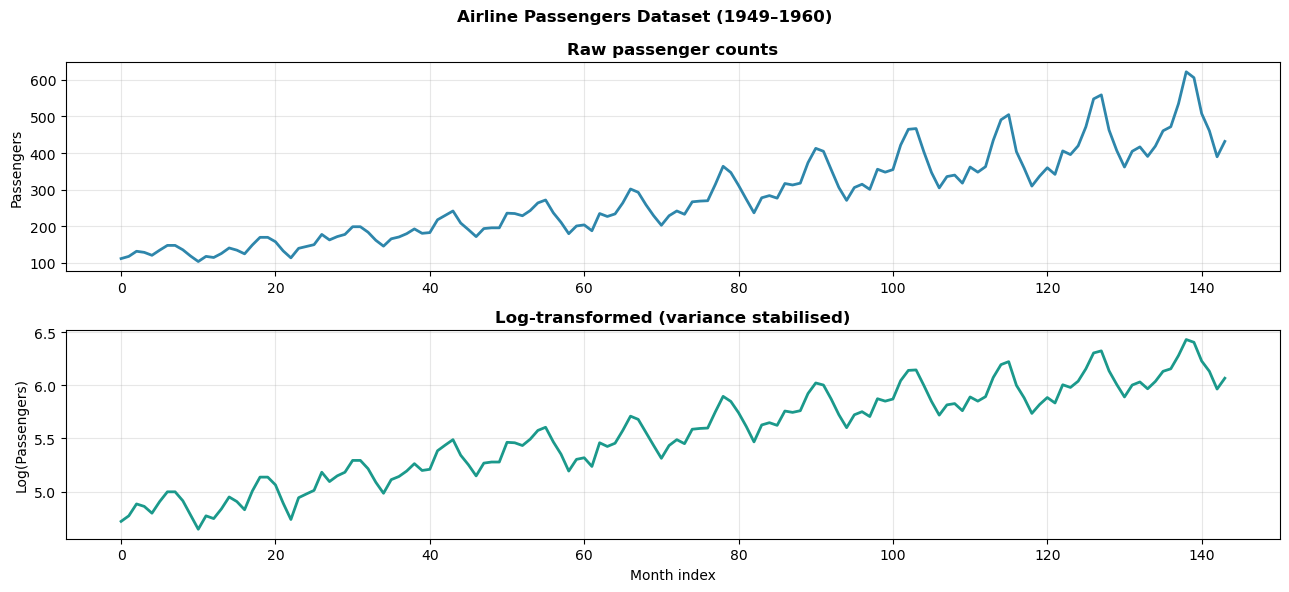

In [12]:
# ── Load and inspect airline passengers dataset ───────────────────────────────

import urllib.request, io

# Download from statsmodels data
url = ("https://raw.githubusercontent.com/jbrownlee/Datasets/master/"
       "airline-passengers.csv")
try:
    with urllib.request.urlopen(url, timeout=5) as r:
        df = pd.read_csv(io.StringIO(r.read().decode()))
    df.columns = ['Month', 'Passengers']
    print("Dataset loaded from URL.")
except Exception:
    # Fallback: generate synthetic data with same statistical properties
    np.random.seed(42)
    months = pd.date_range('1949-01', periods=144, freq='MS')
    trend  = np.linspace(112, 622, 144)
    season = 60 * np.sin(np.linspace(0, 12 * 2 * np.pi, 144)) +              20 * np.sin(np.linspace(0, 24 * 2 * np.pi, 144))
    noise  = np.random.randn(144) * 15
    passengers = np.maximum(trend + season + noise, 50).astype(int)
    df = pd.DataFrame({'Month': months.strftime('%Y-%m'), 'Passengers': passengers})
    print("Synthetic airline dataset generated (URL unavailable).")

series = df['Passengers'].values.astype(float)
print(f"\nDataset shape : {df.shape}")
print(f"Period        : {df['Month'].iloc[0]} to {df['Month'].iloc[-1]}")
print(f"Min passengers: {series.min():.0f}")
print(f"Max passengers: {series.max():.0f}")
print(f"Mean          : {series.mean():.1f}")

# Visualise
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
axes[0].plot(series, color='#2E86AB', linewidth=2)
axes[0].set_title('Raw passenger counts', fontweight='bold')
axes[0].set_ylabel('Passengers'); axes[0].grid(alpha=0.3)

log_series = np.log(series)
axes[1].plot(log_series, color='#1B998B', linewidth=2)
axes[1].set_title('Log-transformed (variance stabilised)', fontweight='bold')
axes[1].set_ylabel('Log(Passengers)'); axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Month index')

plt.suptitle('Airline Passengers Dataset (1949–1960)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_airline_eda.png', dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# ── Preprocessing: log → scale → sliding windows ─────────────────────────────

LOOK_BACK  = 12   # use last 12 months to predict next
HORIZON    = 1    # single-step ahead first
TRAIN_FRAC = 0.80

log_series = np.log(series)

(X_air_tr, y_air_tr), (X_air_te, y_air_te), scaler_air = make_sequences(
    log_series, look_back=LOOK_BACK, horizon=HORIZON, train_frac=TRAIN_FRAC)

# Cutoff index for plotting
train_end = int(len(log_series) * TRAIN_FRAC)

print(f"Airline dataset — prepared sequences")
print(f"  look_back     : {LOOK_BACK} months")
print(f"  X_train shape : {X_air_tr.shape}")
print(f"  X_test  shape : {X_air_te.shape}")
print(f"  Scaler range  : [{scaler_air.data_min_[0]:.3f}, {scaler_air.data_max_[0]:.3f}]")
print(f"  Train/test split: {train_end}/{len(log_series)- train_end} months")


Airline dataset — prepared sequences
  look_back     : 12 months
  X_train shape : (105, 12, 1)
  X_test  shape : (27, 12, 1)
  Scaler range  : [4.644, 6.433]
  Train/test split: 115/29 months


In [14]:
# ── Stacked LSTM for airline forecasting ─────────────────────────────────────

def build_stacked_lstm(look_back, units_1=64, units_2=32, dropout=0.2):
    model = keras.Sequential([
        layers.Input(shape=(look_back, 1)),

        # First LSTM — return_sequences=True to feed into second LSTM
        layers.LSTM(units_1, return_sequences=True,
                    dropout=dropout, recurrent_dropout=0.1,
                    name='lstm_1'),

        # Second LSTM — condenses temporal info into single vector
        layers.LSTM(units_2, dropout=dropout,
                    name='lstm_2'),

        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ], name='Stacked_LSTM_Airline')

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

model_airline = build_stacked_lstm(LOOK_BACK)
model_airline.summary()


Model: "Stacked_LSTM_Airline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ── Train with LR schedule ───────────────────────────────────────────────────

def lr_schedule(epoch, lr):
    """Cosine decay warmup schedule."""
    if epoch < 10:
        return lr
    return lr * 0.95

cbs = [
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True,
                                  monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, verbose=0),
    keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
]

hist_airline = model_airline.fit(
    X_air_tr, y_air_tr,
    epochs=200, batch_size=16,
    validation_split=0.15,
    callbacks=cbs, verbose=0
)
print(f"Training complete. Epochs: {len(hist_airline.history['loss'])}")

# ── Inverse-transform predictions back to original scale ─────────────────────
def inv_transform(scaler, scaled_values):
    """Undo MinMaxScaler then undo log transform."""
    log_vals = scaler.inverse_transform(scaled_values.reshape(-1, 1)).flatten()
    return np.exp(log_vals)

preds_scaled = model_airline.predict(X_air_te, verbose=0)
preds_orig   = inv_transform(scaler_air, preds_scaled.flatten())
true_orig    = inv_transform(scaler_air, y_air_te.flatten())

rmse_air = np.sqrt(mean_squared_error(true_orig, preds_orig))
mae_air  = mean_absolute_error(true_orig, preds_orig)
mape_air = np.mean(np.abs((true_orig - preds_orig) / true_orig)) * 100

print(f"\nTest set metrics (original scale):")
print(f"  RMSE : {rmse_air:.2f} passengers")
print(f"  MAE  : {mae_air:.2f} passengers")
print(f"  MAPE : {mape_air:.2f}%")


Training complete. Epochs: 28

Test set metrics (original scale):
  RMSE : 81.52 passengers
  MAE  : 58.28 passengers
  MAPE : 12.04%


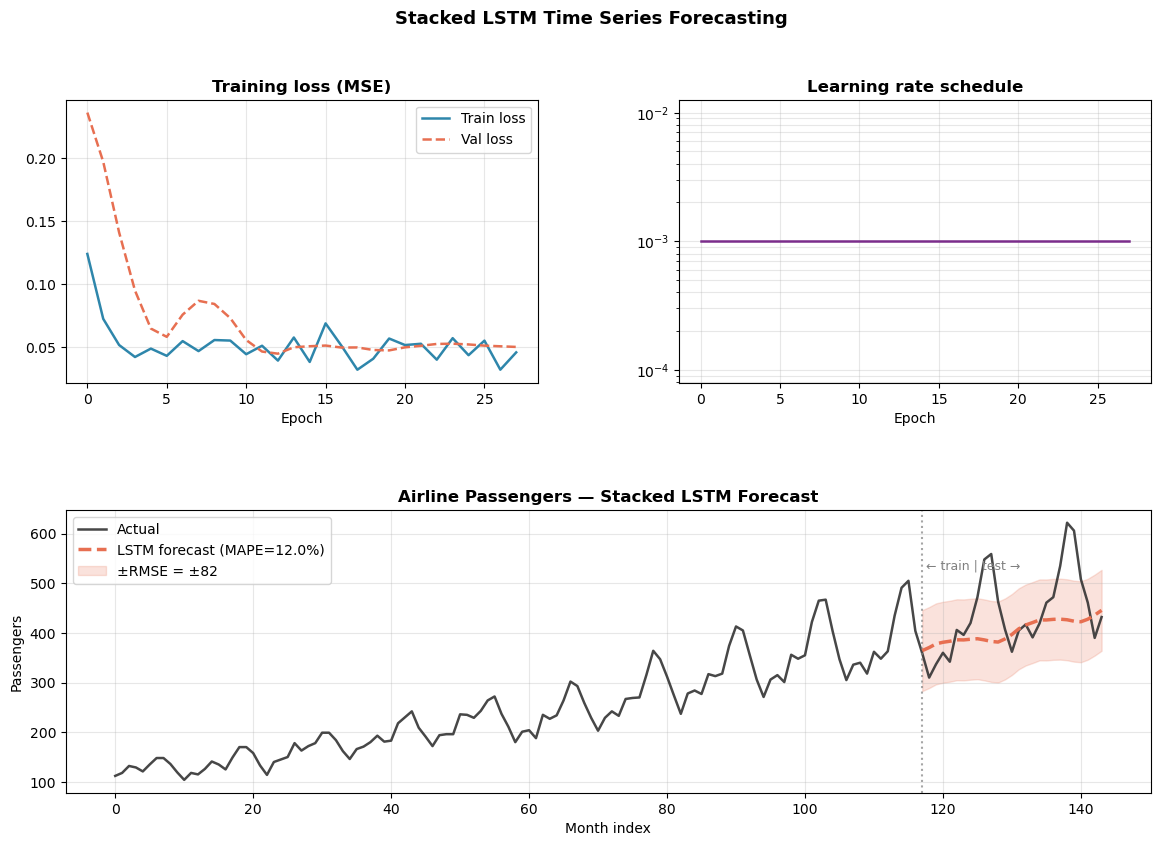

In [16]:
# ── Plot: train/val loss + forecast vs actuals ────────────────────────────────

fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── Training curves ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(hist_airline.history['loss'],     label='Train loss', color='#2E86AB', lw=1.8)
ax1.plot(hist_airline.history['val_loss'], label='Val loss',   color='#E76F51',
         lw=1.8, linestyle='--')
ax1.set_title('Training loss (MSE)', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

# ── Learning rate ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(hist_airline.history.get('lr', [1e-3] * len(hist_airline.history['loss'])),
             color='#7B2D8B', lw=1.8)
ax2.set_title('Learning rate schedule', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.grid(alpha=0.3, which='both')

# ── Full series forecast ──
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(series, color='#333333', linewidth=1.8, label='Actual', alpha=0.9)

# Overlay test predictions at correct positions
test_start = len(series) - len(preds_orig)
test_idx   = np.arange(test_start, test_start + len(preds_orig))
ax3.plot(test_idx, preds_orig, color='#E76F51', linewidth=2.5,
         linestyle='--', label=f'LSTM forecast (MAPE={mape_air:.1f}%)', zorder=5)
ax3.axvline(test_start, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax3.text(test_start + 0.5, series.max() * 0.85, '← train | test →',
         fontsize=9, color='gray')

# Confidence band (±1 RMSE)
ax3.fill_between(test_idx, preds_orig - rmse_air, preds_orig + rmse_air,
                 alpha=0.2, color='#E76F51', label=f'±RMSE = ±{rmse_air:.0f}')

ax3.set_title('Airline Passengers — Stacked LSTM Forecast', fontweight='bold')
ax3.set_xlabel('Month index'); ax3.set_ylabel('Passengers')
ax3.legend(loc='upper left'); ax3.grid(alpha=0.3)

plt.suptitle('Stacked LSTM Time Series Forecasting', fontsize=13, fontweight='bold')
plt.savefig('fig_airline_forecast.png', dpi=120, bbox_inches='tight')
plt.show()


Recursive 24-step-ahead forecast
  Seed window     : 12 months
  Forecast horizon: 24 months (2 years)
  RMSE            : 90.22 passengers


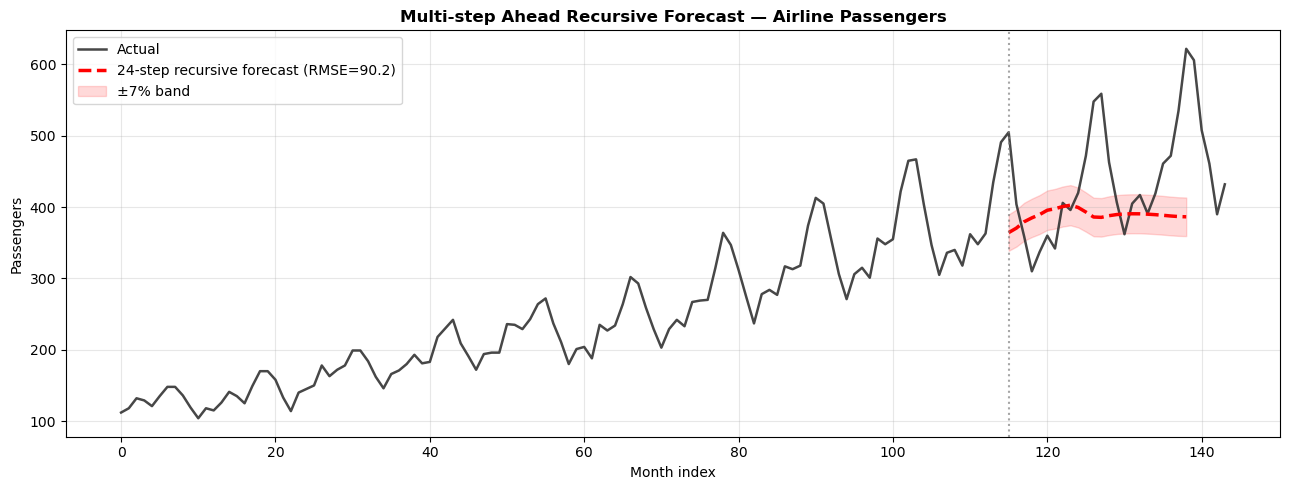


Note: error accumulates with horizon — longer forecasts are less reliable.
Mitigation: use encoder-decoder (seq2seq) or direct multi-output prediction.


In [17]:
# ── Multi-step ahead recursive forecast ──────────────────────────────────────

def recursive_forecast(model, seed_seq, n_steps, scaler):
    """
    Recursively generate n_steps predictions.
    Each prediction is fed back as input for the next step.

    seed_seq : np.ndarray of shape (look_back, 1) — seed window (scaled)
    Returns  : np.ndarray of shape (n_steps,) in original passenger scale
    """
    current = seed_seq.copy()    # (look_back, 1)
    preds   = []
    for _ in range(n_steps):
        x_in    = current[np.newaxis, ...]           # (1, look_back, 1)
        y_hat   = model.predict(x_in, verbose=0)[0, 0]
        preds.append(y_hat)
        current = np.roll(current, -1, axis=0)
        current[-1] = y_hat

    # Inverse transform
    preds_log  = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    return np.exp(preds_log)

# Use the last training window as seed
seed = X_air_te[0]                  # (12, 1) — first test window
multi_preds = recursive_forecast(model_airline, seed, n_steps=24, scaler=scaler_air)

# True values for the corresponding period
true_future = series[train_end : train_end + 24]

rmse_multi = np.sqrt(mean_squared_error(true_future[:len(multi_preds)], multi_preds))
print(f"Recursive 24-step-ahead forecast")
print(f"  Seed window     : {LOOK_BACK} months")
print(f"  Forecast horizon: 24 months (2 years)")
print(f"  RMSE            : {rmse_multi:.2f} passengers")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(range(len(series)), series, color='#333333', lw=1.8, label='Actual', alpha=0.9)
fore_idx = np.arange(train_end, train_end + len(multi_preds))
ax.plot(fore_idx, multi_preds, 'r--', lw=2.5,
        label=f'24-step recursive forecast (RMSE={rmse_multi:.1f})')
ax.fill_between(fore_idx, multi_preds * 0.93, multi_preds * 1.07,
                alpha=0.15, color='red', label='±7% band')
ax.axvline(train_end, color='gray', linestyle=':', lw=1.5, alpha=0.7)
ax.set_title('Multi-step Ahead Recursive Forecast — Airline Passengers',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Month index'); ax.set_ylabel('Passengers')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_multi_step_forecast.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nNote: error accumulates with horizon — longer forecasts are less reliable.")
print("Mitigation: use encoder-decoder (seq2seq) or direct multi-output prediction.")


---
## Case 3: Sentiment Analysis on IMDb Movie Reviews

**Dataset:** 50,000 IMDb movie reviews — 25,000 train / 25,000 test.
Each review is labelled positive (1) or negative (0).
Available directly via `keras.datasets.imdb`.

**Goal:** Binary text classification using:
1. **Embedding layer** — learn dense word representations end-to-end
2. **Bidirectional LSTM** — process each review in both directions
3. **Stacked + regularized LSTM** — compare depth vs. width

**NLP pipeline:**
```
Raw text → Tokenize → Pad sequences → Embedding → LSTM → Sigmoid
```

**Key concepts:**
- **Vocabulary size** — how many unique words to track
- **Sequence padding** — fixed-length inputs for batching
- **Word embeddings** — dense representation vs. one-hot
- **Bidirectionality** — future context improves classification


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
IMDb dataset loaded.
  Train samples : 25,000  |  Test samples: 25,000
  Positive reviews (train): 12,500  (50%)
  Vocabulary size: 10,000

  Review length stats:
    Mean    : 239 tokens
    Median  : 178 tokens
    Max     : 2494 tokens
    > MAX_LEN: 10,677 reviews (42.7%) — will be truncated


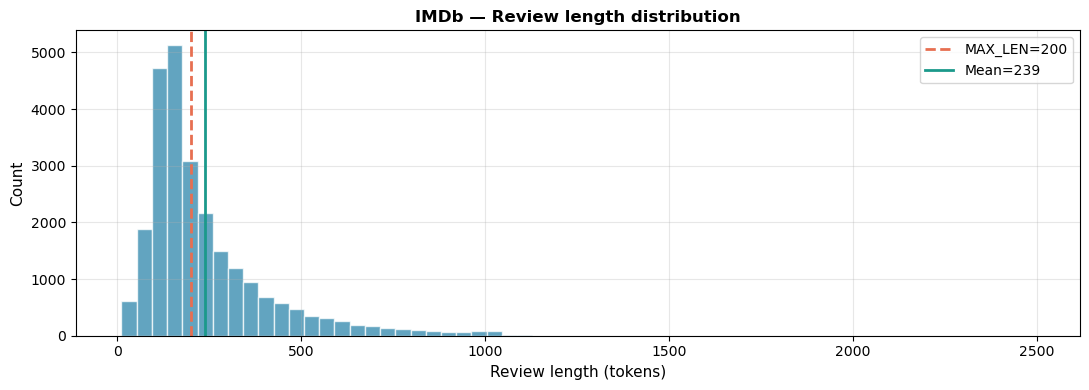

In [18]:
# ── Load and inspect IMDb dataset ────────────────────────────────────────────

VOCAB_SIZE  = 10_000   # keep top 10,000 most frequent words
MAX_LEN     = 200      # truncate / pad all reviews to 200 tokens

(X_imdb_tr, y_imdb_tr), (X_imdb_te, y_imdb_te) = keras.datasets.imdb.load_data(
    num_words=VOCAB_SIZE)

print(f"IMDb dataset loaded.")
print(f"  Train samples : {len(X_imdb_tr):,}  |  Test samples: {len(X_imdb_te):,}")
print(f"  Positive reviews (train): {y_imdb_tr.sum():,}  ({y_imdb_tr.mean()*100:.0f}%)")
print(f"  Vocabulary size: {VOCAB_SIZE:,}")

# Review length distribution
lengths = [len(r) for r in X_imdb_tr]
print(f"\n  Review length stats:")
print(f"    Mean    : {np.mean(lengths):.0f} tokens")
print(f"    Median  : {np.median(lengths):.0f} tokens")
print(f"    Max     : {np.max(lengths)} tokens")
print(f"    > MAX_LEN: {sum(l > MAX_LEN for l in lengths):,} reviews ({sum(l>MAX_LEN for l in lengths)/len(lengths)*100:.1f}%) — will be truncated")

# Visualise length distribution
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(lengths, bins=60, color='#2E86AB', alpha=0.75, edgecolor='white')
ax.axvline(MAX_LEN,       color='#E76F51', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
ax.axvline(np.mean(lengths), color='#1B998B', linestyle='-', lw=2,
           label=f'Mean={np.mean(lengths):.0f}')
ax.set_xlabel('Review length (tokens)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('IMDb — Review length distribution', fontweight='bold', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_imdb_lengths.png', dpi=120, bbox_inches='tight')
plt.show()


In [19]:
# ── Sequence padding ──────────────────────────────────────────────────────────

from tensorflow.keras.preprocessing.sequence import pad_sequences

X_imdb_tr_pad = pad_sequences(X_imdb_tr, maxlen=MAX_LEN,
                               padding='pre',   # pad zeros at the START
                               truncating='pre') # truncate START if too long
X_imdb_te_pad = pad_sequences(X_imdb_te, maxlen=MAX_LEN,
                               padding='pre', truncating='pre')

print(f"After padding:")
print(f"  X_train : {X_imdb_tr_pad.shape}  (samples × tokens)")
print(f"  X_test  : {X_imdb_te_pad.shape}")
print()

# Decode a sample review to verify correctness
word_index = keras.datasets.imdb.get_word_index()
idx_to_word = {v + 3: k for k, v in word_index.items()}
idx_to_word.update({0: '<pad>', 1: '<start>', 2: '<unk>', 3: '<unused>'})

sample_rev = X_imdb_tr_pad[0]
decoded = ' '.join(idx_to_word.get(i, '?') for i in sample_rev if i > 0)
label   = 'POSITIVE 😊' if y_imdb_tr[0] == 1 else 'NEGATIVE 😞'

print(f"Sample review  [{label}]:")
print(f"  {decoded[:300]}...")


After padding:
  X_train : (25000, 200)  (samples × tokens)
  X_test  : (25000, 200)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Sample review  [POSITIVE 😊]:
  and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so m...


In [20]:
# ── Model A: Embedding + Bidirectional LSTM ───────────────────────────────────

EMBED_DIM  = 64    # word embedding dimensionality

def build_bilstm_sentiment(vocab_size, max_len, embed_dim):
    model = keras.Sequential([
        # Learns a 64-dim dense vector for each of the 10,000 vocab tokens
        layers.Embedding(vocab_size, embed_dim, input_length=max_len,
                         mask_zero=True,         # ignore padding tokens
                         name='word_embedding'),

        # Process sequence in both directions — captures past AND future context
        layers.Bidirectional(
            layers.LSTM(64, dropout=0.3, recurrent_dropout=0.1),
            name='bi_lstm'
        ),                                        # output: 128-dim (64 forward + 64 backward)

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid', name='sentiment_output')
    ], name='BiLSTM_Sentiment')

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

model_bilstm = build_bilstm_sentiment(VOCAB_SIZE, MAX_LEN, EMBED_DIM)
model_bilstm.summary()

# Count embedding parameters
embed_params = VOCAB_SIZE * EMBED_DIM
print(f"\nEmbedding layer: {VOCAB_SIZE:,} words × {EMBED_DIM} dims = {embed_params:,} parameters")
print(f"These are LEARNED end-to-end — the model discovers which word vectors minimise the loss.")


Model: "BiLSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm (Bidirectional)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Embedding layer: 10,000 words × 64 dims = 640,000 parameters
These are LEARNED end-to-end — the model discovers which word vectors minimise the loss.


In [21]:
# ── Train BiLSTM ──────────────────────────────────────────────────────────────

cbs_imdb = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True,
                                  monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=0),
]

hist_bilstm = model_bilstm.fit(
    X_imdb_tr_pad, y_imdb_tr,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=cbs_imdb,
    verbose=1
)

test_loss, test_acc, test_auc = model_bilstm.evaluate(
    X_imdb_te_pad, y_imdb_te, verbose=0)
print(f"\n{'='*45}")
print(f"  BiLSTM Test Accuracy  : {test_acc*100:.2f}%")
print(f"  BiLSTM Test AUC       : {test_auc:.4f}")
print(f"  BiLSTM Test Loss      : {test_loss:.4f}")
print(f"{'='*45}")


Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 277ms/step - accuracy: 0.7633 - auc: 0.8536 - loss: 0.4763 - val_accuracy: 0.8760 - val_auc: 0.9446 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 48s 274ms/step - accuracy: 0.8996 - auc: 0.9589 - loss: 0.2577 - val_accuracy: 0.8796 - val_auc: 0.9475 - val_loss: 0.3250 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 52s 296ms/step - accuracy: 0.9232 - auc: 0.9728 - loss: 0.2070 - val_accuracy: 0.8752 - val_auc: 0.9477 - val_loss: 0.3634 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 58s 328ms/step - accuracy: 0.9454 - auc: 0.9841 - loss: 0.1552 - val_accuracy: 0.8696 - val_auc: 0.9431 - val_loss: 0.3638 - learning_rate: 5.0000e-04
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 58s 329ms/step - accuracy: 0.9544 - auc: 0.9884 - loss: 0.1309 - val_accuracy: 0.8676 - val_auc: 0.9422 - val_loss: 0.3693 - learning_rate: 5.0000e-04

  BiLSTM Test Accuracy  : 87.36%
  BiLSTM Test AUC      

In [22]:
# ── Model B: Stacked LSTM for comparison ─────────────────────────────────────

def build_stacked_lstm_sentiment(vocab_size, max_len, embed_dim):
    model = keras.Sequential([
        layers.Embedding(vocab_size, embed_dim, input_length=max_len,
                         mask_zero=True, name='embedding'),
        layers.LSTM(128, return_sequences=True,
                    dropout=0.3, recurrent_dropout=0.1, name='lstm_1'),
        layers.LSTM(64,  dropout=0.3, name='lstm_2'),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name='Stacked_LSTM_Sentiment')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

model_stacked = build_stacked_lstm_sentiment(VOCAB_SIZE, MAX_LEN, EMBED_DIM)

hist_stacked = model_stacked.fit(
    X_imdb_tr_pad, y_imdb_tr,
    epochs=10, batch_size=128, validation_split=0.1,
    callbacks=cbs_imdb, verbose=0
)
_, stk_acc, stk_auc = model_stacked.evaluate(X_imdb_te_pad, y_imdb_te, verbose=0)
print(f"Stacked LSTM Test Accuracy: {stk_acc*100:.2f}%  AUC: {stk_auc:.4f}")


Stacked LSTM Test Accuracy: 86.26%  AUC: 0.9367


In [23]:
# ── Full evaluation and comparison ───────────────────────────────────────────

y_pred_bi  = (model_bilstm.predict(X_imdb_te_pad, verbose=0) > 0.5).astype(int)
y_pred_stk = (model_stacked.predict(X_imdb_te_pad, verbose=0) > 0.5).astype(int)

print("BiLSTM Classification Report:")
print(classification_report(y_imdb_te, y_pred_bi,
                             target_names=['Negative', 'Positive']))
print("Stacked LSTM Classification Report:")
print(classification_report(y_imdb_te, y_pred_stk,
                             target_names=['Negative', 'Positive']))


BiLSTM Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.88      0.87     12500
    Positive       0.88      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000

Stacked LSTM Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86     12500
    Positive       0.86      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



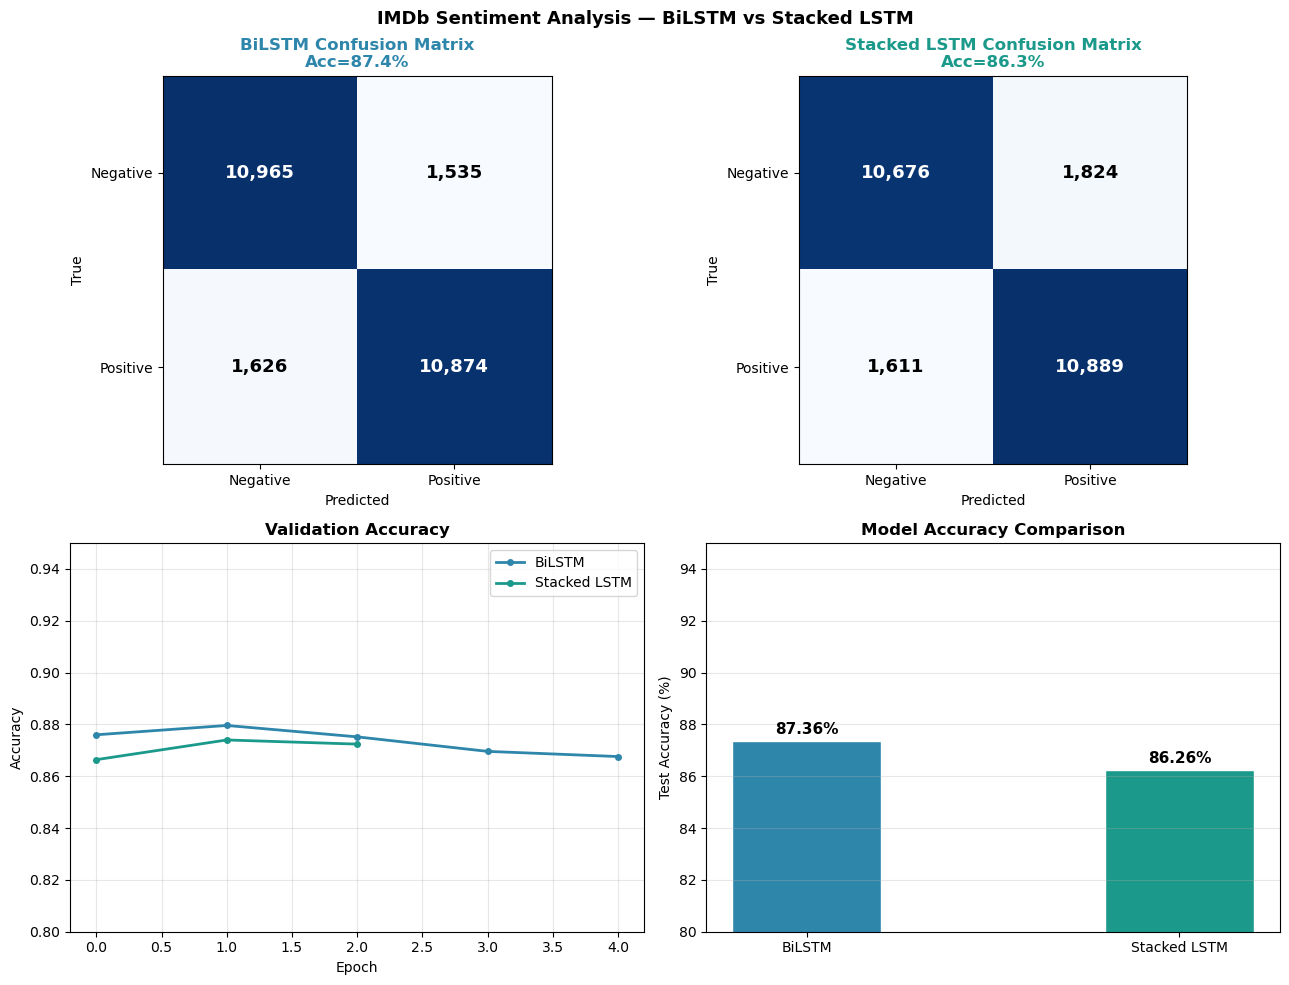

In [24]:
# ── Visualise: confusion matrices + training curves ───────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Confusion matrices
for ax, y_pred, title, color in zip(
    [axes[0,0], axes[0,1]],
    [y_pred_bi, y_pred_stk],
    ['BiLSTM', 'Stacked LSTM'],
    ['#2E86AB', '#1B998B']
):
    cm = confusion_matrix(y_imdb_te, y_pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Negative','Positive']); ax.set_yticklabels(['Negative','Positive'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(
        f'{title} Confusion Matrix\nAcc={cm.diagonal().sum()/cm.sum()*100:.1f}%',
                 fontweight='bold', color=color)
    for (r, c), val in np.ndenumerate(cm):
        ax.text(c, r, f'{val:,}', ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='white' if val > cm.max()*0.5 else 'black')

# Training accuracy comparison
for hist, label, color in [
    (hist_bilstm, 'BiLSTM', '#2E86AB'),
    (hist_stacked, 'Stacked LSTM', '#1B998B')
]:
    axes[1,0].plot(hist.history['val_accuracy'], label=label,
                   color=color, lw=2.0, marker='o', markersize=4)
axes[1,0].set_title('Validation Accuracy', fontweight='bold')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3); axes[1,0].set_ylim(0.8, 0.95)

# Model comparison bar chart
models  = ['BiLSTM', 'Stacked LSTM']
accs    = [test_acc * 100, stk_acc * 100]
colors  = ['#2E86AB', '#1B998B']
bars    = axes[1,1].bar(models, accs, color=colors, edgecolor='white', width=0.4)
axes[1,1].set_ylim(80, 95); axes[1,1].set_ylabel('Test Accuracy (%)')
axes[1,1].set_title('Model Accuracy Comparison', fontweight='bold')
axes[1,1].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, acc + 0.15,
                   f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('IMDb Sentiment Analysis — BiLSTM vs Stacked LSTM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_imdb_results.png', dpi=120, bbox_inches='tight')
plt.show()


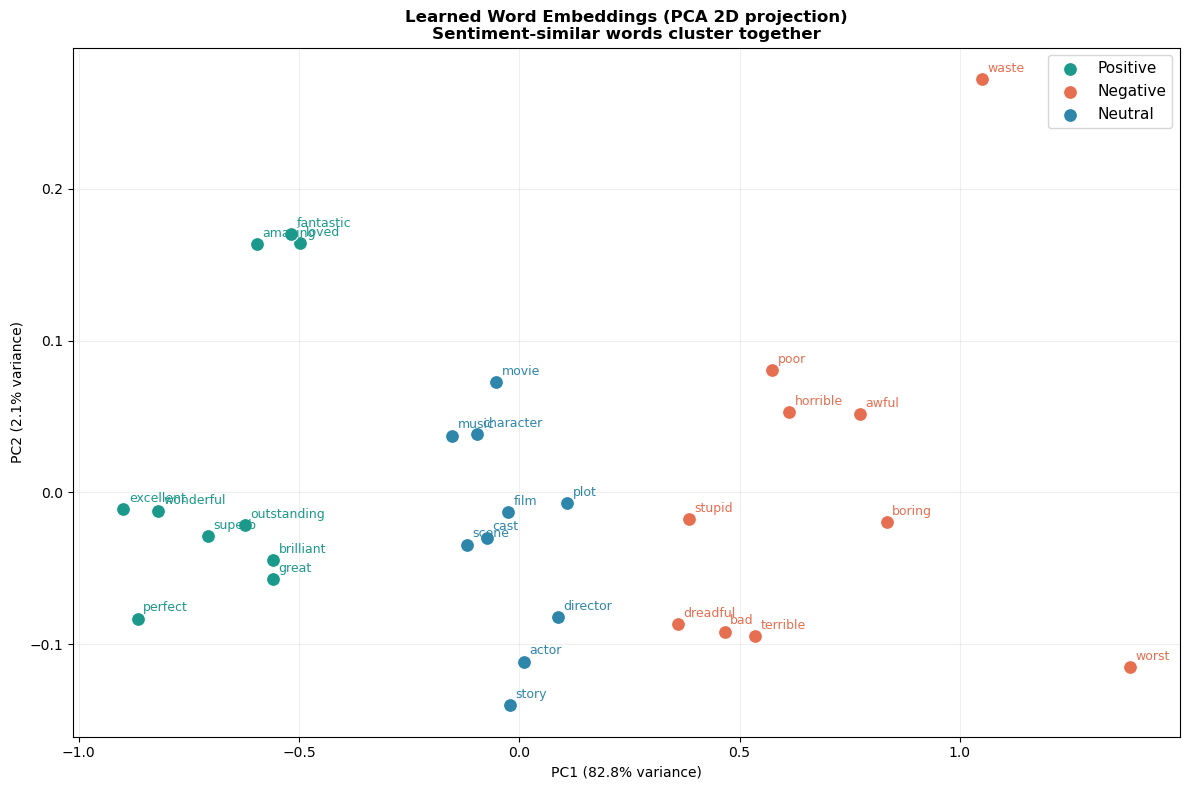

Positive and negative words separate in embedding space — the model learned sentiment geometry.


In [25]:
# ── Visualise learned word embeddings via PCA ─────────────────────────────────

from sklearn.decomposition import PCA

# Extract the learned embedding weights
embed_weights = model_bilstm.get_layer('word_embedding').get_weights()[0]  # (10000, 64)

# Words to inspect — sentiment-laden vocabulary
interest_words = {
    'positive': ['brilliant', 'excellent', 'wonderful', 'outstanding', 'superb',
                 'perfect', 'loved', 'amazing', 'great', 'fantastic'],
    'negative': ['terrible', 'awful', 'boring', 'worst', 'horrible',
                 'dreadful', 'stupid', 'waste', 'bad', 'poor'],
    'neutral' : ['film', 'movie', 'story', 'character', 'scene',
                 'director', 'actor', 'plot', 'cast', 'music'],
}

word_index = keras.datasets.imdb.get_word_index()

# Collect embeddings for words of interest
vecs, labels_vis, group_labels = [], [], []
colors_vis = {'positive': '#1B998B', 'negative': '#E76F51', 'neutral': '#2E86AB'}

for group, words in interest_words.items():
    for word in words:
        idx = word_index.get(word)
        if idx is not None and idx < VOCAB_SIZE:
            vecs.append(embed_weights[idx + 3])  # +3 offset (keras convention)
            labels_vis.append(word)
            group_labels.append(group)

vecs = np.array(vecs)
pca  = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vecs)

fig, ax = plt.subplots(figsize=(12, 8))
for group in ['positive', 'negative', 'neutral']:
    mask  = [g == group for g in group_labels]
    pts   = coords[mask]
    color = colors_vis[group]
    ax.scatter(pts[:, 0], pts[:, 1], c=color, s=100, label=group.capitalize(),
               edgecolors='white', linewidths=0.8, zorder=3)
    for i, (x, y) in enumerate(pts):
        lbl = [l for l, m in zip(labels_vis, mask) if m][i]
        ax.annotate(lbl, (x, y), fontsize=9, ha='left', va='bottom',
                    xytext=(4, 3), textcoords='offset points', color=color)

ax.set_title(
    'Learned Word Embeddings (PCA 2D projection)\n'
    'Sentiment-similar words cluster together',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=11); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig_embeddings_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print("Positive and negative words separate in embedding space — the model learned sentiment geometry.")


In [26]:
# ── Inference on custom reviews ───────────────────────────────────────────────

def predict_sentiment(model, reviews, word_index, max_len=200, vocab_size=10_000):
    """
    Predict sentiment for a list of raw text reviews.
    Returns (probability of positive, label)
    """
    from tensorflow.keras.preprocessing.text import text_to_word_sequence

    encoded = []
    for review in reviews:
        tokens = text_to_word_sequence(review)
        seq    = [min(word_index.get(w, 2) + 3, vocab_size - 1) for w in tokens]
        encoded.append(seq)

    padded = pad_sequences(encoded, maxlen=max_len, padding='pre', truncating='pre')
    probs  = model.predict(padded, verbose=0).flatten()
    return probs

custom_reviews = [
    "This was an absolutely brilliant film. The acting was superb and the story was deeply moving.",
    "Terrible waste of time. Boring plot, wooden acting. I fell asleep in the first 20 minutes.",
    "It was okay. Some good scenes but the ending felt rushed and the characters were underdeveloped.",
    "One of the best films I have seen this decade. Masterful direction and outstanding performances.",
    "Awful. Just awful. The worst movie ever made. Do not watch this garbage.",
]

word_index = keras.datasets.imdb.get_word_index()
probs = predict_sentiment(model_bilstm, custom_reviews, word_index)

print(f"Custom review predictions (BiLSTM):\n")
print(f"{'P(positive)':>14}  {'Label':>10}  Review")
print("-" * 90)
for prob, review in zip(probs, custom_reviews):
    label = 'POSITIVE 😊' if prob > 0.5 else 'NEGATIVE 😞'
    print(f"  {prob:>12.4f}  {label:>12}  {review[:65]}...")


Custom review predictions (BiLSTM):

   P(positive)       Label  Review
------------------------------------------------------------------------------------------
        0.9947    POSITIVE 😊  This was an absolutely brilliant film. The acting was superb and ...
        0.0000    NEGATIVE 😞  Terrible waste of time. Boring plot, wooden acting. I fell asleep...
        0.2735    NEGATIVE 😞  It was okay. Some good scenes but the ending felt rushed and the ...
        0.9960    POSITIVE 😊  One of the best films I have seen this decade. Masterful directio...
        0.0000    NEGATIVE 😞  Awful. Just awful. The worst movie ever made. Do not watch this g...


---
## Summary & Exam Notes

### Core Concepts

**1. Vanilla RNN mechanics**
The hidden state $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$ carries memory across
time steps via *weight sharing* — the same transformation is applied at every step.
Backpropagation Through Time (BPTT) computes gradients by unrolling this shared graph.

**2. Vanishing gradient problem**
Gradient at step $t$ involves a product of $T-t$ Jacobians, each containing $W_{hh}$
and the tanh derivative ($\leq 1$). For $T > 20$, this product collapses to ~0, making
it impossible to learn long-range dependencies. Exploding gradients are handled by
**gradient clipping**; vanishing gradients require architectural solutions (LSTM/GRU).

**3. LSTM solution — additive cell state**
The LSTM cell state update $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ is *additive*,
not multiplicative. Gradients flow back through $C$ almost unmodified — the highway
metaphor. The four gates (forget, input, output, candidate) learn when to remember,
write, and expose information.

**4. GRU — streamlined LSTM**
Two gates instead of four; merged cell and hidden state. Fewer parameters, comparable
performance, faster training. Default choice when you need long-range memory but
compute is constrained.

**5. Bidirectionality**
Wrapping any RNN in `Bidirectional()` processes the sequence both forward and backward.
For classification and understanding tasks (sentiment, NER, QA), bidirectional models
consistently outperform unidirectional ones. Not applicable for *causal* tasks (forecasting).

**6. Sequence preprocessing checklist**
- Time series: log-transform → scale to [−1, 1] → sliding windows
- Text: tokenize → `pad_sequences(padding='pre', truncating='pre')` → embedding
- Validation set is **never** augmented or had its statistics re-computed

**7. Forecasting pitfalls**
- Recursive multi-step forecasting accumulates errors — use seq2seq for long horizons
- Always inverse-transform predictions before computing metrics
- Train/val/test splits must respect temporal ordering — **no random shuffling**

**8. Word embeddings**
The `Embedding` layer maps integer token IDs to dense vectors learned end-to-end.
After training, semantically similar words cluster in embedding space (demonstrated
via PCA). Pre-trained embeddings (GloVe, fastText) can be loaded as fixed initial
weights and optionally fine-tuned.

---

### Quick Reference: Keras RNN Boilerplate

```python
# Single-layer Bidirectional LSTM classifier
model = keras.Sequential([
    layers.Embedding(vocab_size, embed_dim, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64, dropout=0.3, recurrent_dropout=0.1)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid'),   # binary
])

# Stacked LSTM time series regressor
model = keras.Sequential([
    layers.Input(shape=(look_back, n_features)),
    layers.LSTM(64, return_sequences=True, dropout=0.2),
    layers.LSTM(32, dropout=0.2),
    layers.Dense(1),
])
```

---
*DLA Notebook 3 — Deep Learning Algorithms · PhD in Data Science 2028 · AIM*
*Prof. Christopher P. Monterola · Sessions 12–13*
